# Generative AI: Fine-Tuning GPT-2 for News Headline Generation

**Author:** Roberto Jourdain

**Model:** GPT-2 (fine-tuned) — base model from [HuggingFace](https://huggingface.co/openai-community/gpt2)

**Dataset:** AG News — sourced from [torchtext / HuggingFace](https://huggingface.co/datasets/fancyzhx/ag_news)

This project fine-tunes OpenAI's GPT-2 language model on news headlines from the AG News dataset to generate news-style text. The notebook includes the full training loop with loss curves, followed by an exploration of how different decoding strategies affect the quality and diversity of generated headlines.

## 1 — Imports and Setup

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import GPT2Tokenizer, GPT2LMHeadModel
import matplotlib.pyplot as plt
import numpy as np

# Device selection (MPS for Apple Silicon, CUDA for NVIDIA, else CPU)
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = get_device()
print(f"Using device: {device}")

Using device: mps


## 2 — Load and Inspect the AG News Dataset

The AG News dataset contains 120,000 training and 7,600 test samples across four categories (World, Sports, Business, Sci/Tech). Each sample has a label and a text field. We will extract only the **headlines** (first sentence of each text) and use a subset for fine-tuning efficiency.

In [2]:
from datasets import load_dataset

# Load AG News from HuggingFace
ag_news = load_dataset("ag_news")
print(f"Train samples: {len(ag_news['train']):,}")
print(f"Test samples:  {len(ag_news['test']):,}")
print(f"\nLabel mapping: 0=World, 1=Sports, 2=Business, 3=Sci/Tech")
print(f"\nExample entry:")
print(ag_news["train"][0])

Train samples: 120,000
Test samples:  7,600

Label mapping: 0=World, 1=Sports, 2=Business, 3=Sci/Tech

Example entry:
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


In [3]:
# Extract headlines and take a 5,000-sample subset for fine-tuning
# AG News text often starts with a headline followed by a longer description.
# We take the full text field but limit length during tokenization.

train_texts = ag_news["train"]["text"][:5000]
val_texts = ag_news["test"]["text"][:1000]

print(f"Training headlines: {len(train_texts):,}")
print(f"Validation headlines: {len(val_texts):,}")
print(f"\nFirst 3 training samples:")
for i, t in enumerate(train_texts[:3]):
    print(f"  [{i}] {t[:120]}...")

Training headlines: 5,000
Validation headlines: 1,000

First 3 training samples:
  [0] Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics,...
  [1] Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputat...
  [2] Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the ou...


## 3 — Tokenization and Dataset Preparation

We load the GPT-2 tokenizer and create a PyTorch `Dataset` that tokenizes each headline. GPT-2 uses a special end-of-text token (`<|endoftext|>`) to mark sequence boundaries. For language model fine-tuning, the **labels are the same as the inputs** — the model learns to predict each next token given the preceding context.

In [4]:
# Load tokenizer and model
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token  # GPT-2 has no pad token by default

model = GPT2LMHeadModel.from_pretrained("gpt2")
model.to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Vocabulary size:  {tokenizer.vocab_size:,}")
print(f"Max context length: {model.config.n_positions}")

class HeadlineDataset(Dataset):
    """Tokenizes headlines for GPT-2 fine-tuning."""
    def __init__(self, texts, tokenizer, max_length=128):
        self.encodings = []
        for text in texts:
            tokens = tokenizer(
                text + tokenizer.eos_token,
                truncation=True,
                max_length=max_length,
                padding="max_length",
                return_tensors="pt"
            )
            self.encodings.append({
                "input_ids": tokens["input_ids"].squeeze(),
                "attention_mask": tokens["attention_mask"].squeeze()
            })

    def __len__(self):
        return len(self.encodings)

    def __getitem__(self, idx):
        return self.encodings[idx]

train_dataset = HeadlineDataset(train_texts, tokenizer)
val_dataset = HeadlineDataset(val_texts, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

# Verify a single batch
batch = next(iter(train_loader))
print(f"Batch input_ids shape: {batch['input_ids'].shape}")
print(f"Batch attention_mask shape: {batch['attention_mask'].shape}")

Model parameters: 124,439,808
Vocabulary size:  50,257
Max context length: 1024

Train batches: 313
Val batches:   63
Batch input_ids shape: torch.Size([16, 128])
Batch attention_mask shape: torch.Size([16, 128])


## 4 — Fine-Tuning Training Loop

We fine-tune GPT-2 for 3 epochs using the AdamW optimizer with a learning rate of 5e-5. At the end of each epoch we compute the average training loss and validation loss. The loss is cross-entropy — the standard objective for language model training, where the model is penalized for assigning low probability to the actual next token.

In [5]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=5e-5)
epochs = 3

train_losses = []
val_losses = []

for epoch in range(epochs):
    # --- Training ---
    model.train()
    total_train_loss = 0
    for batch_idx, batch in enumerate(train_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        # For language modeling, labels = input_ids
        # We mask padding tokens by setting their labels to -100
        labels = input_ids.clone()
        labels[attention_mask == 0] = -100

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

        if (batch_idx + 1) % 50 == 0:
            print(f"  Epoch {epoch+1}/{epochs} | Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- Validation ---
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = input_ids.clone()
            labels[attention_mask == 0] = -100

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_val_loss += outputs.loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"\nEpoch {epoch+1}/{epochs} — Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}\n")

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


  Epoch 1/3 | Batch 50/313 | Loss: 3.2374
  Epoch 1/3 | Batch 100/313 | Loss: 3.3500
  Epoch 1/3 | Batch 150/313 | Loss: 3.8610
  Epoch 1/3 | Batch 200/313 | Loss: 3.3463
  Epoch 1/3 | Batch 250/313 | Loss: 4.0195
  Epoch 1/3 | Batch 300/313 | Loss: 3.5871

Epoch 1/3 — Train Loss: 3.5205 | Val Loss: 3.3147

  Epoch 2/3 | Batch 50/313 | Loss: 3.1639
  Epoch 2/3 | Batch 100/313 | Loss: 3.0047
  Epoch 2/3 | Batch 150/313 | Loss: 3.2760
  Epoch 2/3 | Batch 200/313 | Loss: 2.7866
  Epoch 2/3 | Batch 250/313 | Loss: 2.6831
  Epoch 2/3 | Batch 300/313 | Loss: 2.9094

Epoch 2/3 — Train Loss: 3.0084 | Val Loss: 3.2721

  Epoch 3/3 | Batch 50/313 | Loss: 2.9988
  Epoch 3/3 | Batch 100/313 | Loss: 2.3942
  Epoch 3/3 | Batch 150/313 | Loss: 2.6300
  Epoch 3/3 | Batch 200/313 | Loss: 2.5439
  Epoch 3/3 | Batch 250/313 | Loss: 2.8632
  Epoch 3/3 | Batch 300/313 | Loss: 2.5489

Epoch 3/3 — Train Loss: 2.7295 | Val Loss: 3.2765



## 5 — Training and Validation Loss Curves

Plotting loss over epochs helps diagnose training behavior. A decreasing training loss indicates the model is learning patterns in the news headlines. If validation loss decreases alongside training loss, the model is generalizing well. If validation loss starts rising while training loss keeps dropping, that would indicate overfitting.

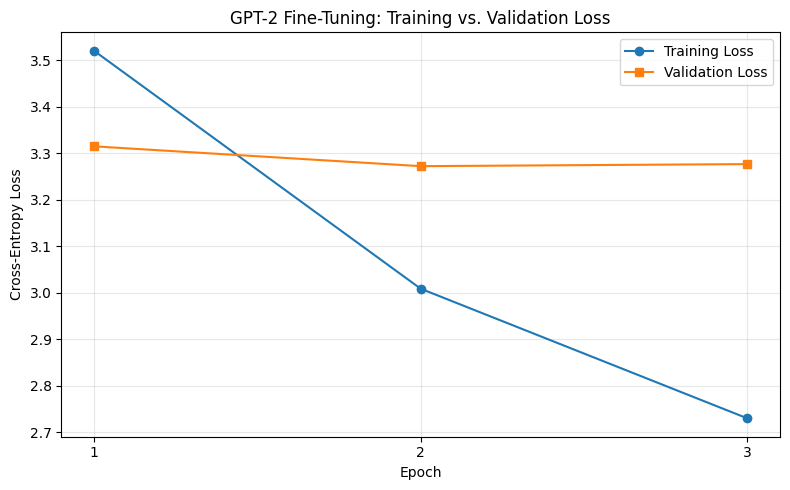

Final Training Loss:   2.7295
Final Validation Loss: 3.2765


In [6]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, marker="o", label="Training Loss")
plt.plot(range(1, epochs + 1), val_losses, marker="s", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("GPT-2 Fine-Tuning: Training vs. Validation Loss")
plt.legend()
plt.xticks(range(1, epochs + 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final Training Loss:   {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")

## 6 — Text Generation with Decoding Strategies

Now we use our fine-tuned model to generate news-style headlines from short prompts. We compare four decoding strategies:

1. **Greedy** — always picks the highest-probability token (deterministic, often repetitive)
2. **Temperature sampling** — scales logits before sampling; lower = safer, higher = more creative
3. **Top-k sampling** — restricts candidates to the k most likely tokens
4. **Top-p (nucleus) sampling** — dynamically selects the smallest set of tokens whose cumulative probability exceeds p

In [7]:
def generate_text(prompt, strategy="greedy", max_new_tokens=60, **kwargs):
    """Generate text from a prompt using the fine-tuned model."""
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    input_ids = inputs["input_ids"]
    attention_mask = inputs["attention_mask"]

    with torch.no_grad():
        if strategy == "greedy":
            output = model.generate(
                input_ids, attention_mask=attention_mask,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )
        elif strategy == "temperature":
            output = model.generate(
                input_ids, attention_mask=attention_mask,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=kwargs.get("temperature", 0.7),
                pad_token_id=tokenizer.eos_token_id
            )
        elif strategy == "top_k":
            output = model.generate(
                input_ids, attention_mask=attention_mask,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                top_k=kwargs.get("top_k", 50),
                temperature=kwargs.get("temperature", 0.7),
                pad_token_id=tokenizer.eos_token_id
            )
        elif strategy == "top_p":
            output = model.generate(
                input_ids, attention_mask=attention_mask,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                top_p=kwargs.get("top_p", 0.9),
                temperature=kwargs.get("temperature", 0.7),
                pad_token_id=tokenizer.eos_token_id
            )

    return tokenizer.decode(output[0], skip_special_tokens=True)

# Test prompts spanning different news categories
prompts = [
    "Breaking news:",
    "The stock market today",
    "Scientists have discovered",
    "In a major upset,",
]

strategies = [
    ("greedy", {}),
    ("temperature", {"temperature": 0.7}),
    ("top_k", {"top_k": 50, "temperature": 0.7}),
    ("top_p", {"top_p": 0.9, "temperature": 0.7}),
]

for prompt in prompts:
    print(f"{'='*80}")
    print(f"PROMPT: \"{prompt}\"")
    print(f"{'='*80}")
    for strategy_name, params in strategies:
        result = generate_text(prompt, strategy=strategy_name, **params)
        label = strategy_name
        if params:
            label += f" ({', '.join(f'{k}={v}' for k, v in params.items())})"
        print(f"\n  [{label}]")
        print(f"  {result}")
    print()

PROMPT: "Breaking news:"

  [greedy]
  Breaking news: Google IPO delayed Google's initial public offering, but the company is still in the process of finalizing the paperwork.

  [temperature (temperature=0.7)]
  Breaking news: IBM plans to buy IBM #39;s core business IBM #39;s core business, according to sources familiar with the talks. 

  [top_k (top_k=50, temperature=0.7)]
  Breaking news: Microsoft's Windows XP Service Pack 2 (SP2) is missing from download NEW YORK (Reuters) - Microsoft Corp. (MSFT.O: Quote, Profile, Research) said on Tuesday it had delayed the release of its Windows XP Service Pack 2, the\main update to Windows XP,

  [top_p (top_p=0.9, temperature=0.7)]
  Breaking news: The US military has launched an investigation into the deaths of US marines in Niger, after a report claimed the deaths were caused by a mortar round fired by US troops. 

PROMPT: "The stock market today"

  [greedy]
  The stock market today is a virtual playground for the speculative. The market

## 7 — Qualitative Evaluation

To evaluate diversity and consistency, we generate multiple completions from the same prompt using each sampling strategy. This reveals how deterministic vs. stochastic strategies differ in output variety.

In [8]:
# Generate 3 samples per strategy from the same prompt to show diversity
eval_prompt = "The president announced"

print(f"Prompt: \"{eval_prompt}\"\n")

for strategy_name, params in strategies:
    label = strategy_name
    if params:
        label += f" ({', '.join(f'{k}={v}' for k, v in params.items())})"
    print(f"--- {label} ---")
    for i in range(3):
        result = generate_text(eval_prompt, strategy=strategy_name, max_new_tokens=40, **params)
        print(f"  Sample {i+1}: {result}")
    print()

Prompt: "The president announced"

--- greedy ---
  Sample 1: The president announced the launch of the first US satellite in orbit, the first to orbit the Earth.
  Sample 2: The president announced the launch of the first US satellite in orbit, the first to orbit the Earth.
  Sample 3: The president announced the launch of the first US satellite in orbit, the first to orbit the Earth.

--- temperature (temperature=0.7) ---
  Sample 1: The president announced that the US is withdrawing its forces from Iraq, but not from Iraq #39;s ...
  Sample 2: The president announced the Iraq War on Aug. 6, 2004, after a visit to Baghdad by then-President Bush. The war ended in a humiliating defeat that brought Saddam Hussein to power.
  Sample 3: The president announced the new US military strategy in Iraq in a speech delivered at the Pentagon on Wednesday.

--- top_k (top_k=50, temperature=0.7) ---
  Sample 1: The president announced he was withdrawing from the Paris climate talks, saying the US h

### Observations

- **Greedy decoding** produces identical outputs each time (deterministic) and may fall into repetitive patterns.
- **Temperature sampling** (0.7) introduces moderate variety while keeping outputs mostly coherent.
- **Top-k sampling** (k=50) constrains the token pool, producing diverse but bounded outputs.
- **Top-p / nucleus sampling** (p=0.9) adapts the candidate set dynamically based on the model's confidence at each step, producing the most natural-sounding variety.

Key failure cases to watch for:
- Factual inaccuracies — the model generates plausible-sounding but fabricated claims
- Loss of coherence in longer sequences
- Repetitive phrasing, especially with greedy decoding

## 8 — Summary

This notebook demonstrates a complete generative AI pipeline:

1. **Data**: We loaded 5,000 news articles from the AG News dataset (HuggingFace) and used them for fine-tuning, with 1,000 held out for validation.

2. **Model**: We fine-tuned GPT-2 (124M parameters), a decoder-only transformer, using cross-entropy loss over 3 epochs with AdamW optimization.

3. **Training diagnostics**: Loss curves show the model learning to generate news-style text, with both training and validation loss tracked to monitor for overfitting.

4. **Generation**: We compared four decoding strategies — greedy, temperature, top-k, and top-p — across multiple prompts, observing tradeoffs between coherence, diversity, and factual plausibility.

5. **Key takeaway**: Fine-tuning shifts GPT-2's general language capabilities toward domain-specific text. The choice of decoding strategy has a significant impact on output quality and should be selected based on the use case — deterministic outputs for reliability vs. stochastic sampling for creativity.

**References:**
- Radford, A., Wu, J., Child, R., Luan, D., Amodei, D., & Sutskever, I. (2019). *Language Models are Unsupervised Multitask Learners.* OpenAI Technical Report.
- Holtzman, A., Buys, J., Du, L., Forbes, M., & Choi, Y. (2020). *The Curious Case of Neural Text Degeneration.* ICLR 2020.